# Reproducing the R package

This notebook reruns the [R stemFinder vignette](https://github.com/CahanLab/stemfinder) on Tabula Muris bone marrow (10x, 3,427 cells) and checks the results against R.

To compare the algorithm itself rather than preprocessing choices, it starts from R's inputs, which ship with the PyStemFinder test suite in `tests/data/bmmc_r_reference.h5ad`:

- `X`: Seurat's scaled expression of the 91 mouse cell cycle genes
- `layers['data']`: Seurat's log-normalized expression of the same genes
- `obsp['distances']`: Seurat's kNN graph (k = 59 on 32 principal components)
- `obs`: each cell's `Phenotype`, its `Ground_truth` differentiation stage (1 = least differentiated), the scores computed by R, and the scores of a competing method, CCAT

In [1]:
import anndata
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import pystemfinder as psf

adata = anndata.read_h5ad("../../tests/data/bmmc_r_reference.h5ad")
adata

AnnData object with n_obs × n_vars = 3427 × 91
    obs: 'Phenotype', 'Ground_truth', 'R_gini_stemFinder_raw', 'R_gini_stemFinder', 'R_stdev_stemFinder_raw', 'R_stdev_stemFinder', 'R_variance_stemFinder_raw', 'R_variance_stemFinder', 'ccat_invert', 'CytoTRACE_invert'
    uns: 'R_markers', 'R_performance', 'R_session'
    obsp: 'distances'
    layers: 'data', None (.X)

## Run stemFinder

The standard markers are the S and G2M phase cell cycle genes. The R package lists E2f8 under both phases, so the R vignette counts it twice; PyStemFinder lists it once, under S (as Seurat does). The R scores in this file were computed with the same 91 genes, so they differ slightly from the vignette's published scores (rank correlation 0.9999).

In [2]:
markers = psf.cell_cycle_genes("mouse")
psf.stemfinder(adata, markers)

adata.obs[["stemfinder_raw", "stemfinder", "R_gini_stemFinder_raw", "R_gini_stemFinder"]].head()

,stemfinder_raw,stemfinder,R_gini_stemFinder_raw,R_gini_stemFinder
X10X_P7_3_AAACCTGAGCATCATC,18.405172,0.088560,18.405172,0.088560
X10X_P7_3_AAACCTGCAGAGTGTG,5.236623,0.740678,5.236623,0.740678
X10X_P7_3_AAACCTGGTCGAACAG,16.156956,0.199894,16.156956,0.199894
X10X_P7_3_AAACCTGTCACTTCAT,19.002973,0.058957,19.002973,0.058957
X10X_P7_3_AAACGGGAGAAGGTTT,2.961653,0.853336,2.961653,0.853336


In [3]:
np.abs(adata.obs["stemfinder_raw"] - adata.obs["R_gini_stemFinder_raw"]).max()

np.float64(6.039613253960852e-14)

The `stemfinder` column is oriented like pseudotime: lower scores mean less differentiated cells.

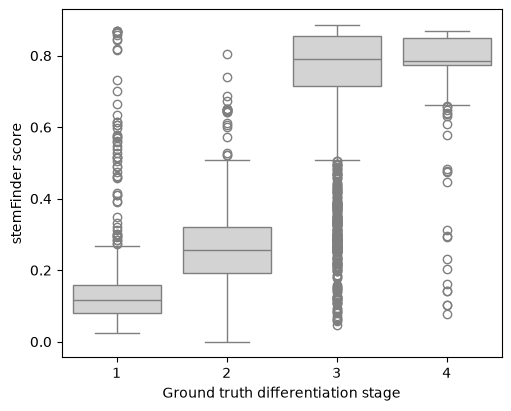

In [4]:
fig, ax = plt.subplots(figsize=(5, 4), layout="constrained")
sns.boxplot(data=adata.obs, x="Ground_truth", y="stemfinder", color="lightgray", ax=ax)
ax.set(xlabel="Ground truth differentiation stage", ylabel="stemFinder score")
plt.show()

## Benchmark against ground truth

`compute_performance` reports the Spearman correlation between scores and ground truth across cells, the correlation between the mean score and mean ground truth of each phenotype, and the AUC for separating the most from the least differentiated cells. Here CCAT is evaluated alongside; its scores are already oriented like pseudotime.

In [5]:
psf.compute_performance(adata, competitor_key="ccat_invert", competitor_inverted=True)

,Spearman_SingleCell,Spearman_Pheno,AUC
stemfinder,0.741173,0.865049,0.966258
ccat_invert,0.675567,0.841153,0.953014


`pct_recover` is the percentage of the least differentiated cells whose score falls in the lowest quantile (one quantile per ground truth stage):

In [6]:
psf.pct_recover(adata)

np.float64(84.71177944862156)

### Differences from R

Two metrics differ from the R package's `compute_performance_single`:

- **AUC** uses every pair of most and least differentiated cells. R's `auc_probability` receives 0/1 numeric labels, so `scores[labels]` repeats the first positive cell's score and the AUC compares only that one cell with the least differentiated cells. R reports 0.972 for stemFinder and 0.930 for CCAT; the exact values are 0.966 and 0.953.
- **Spearman_Pheno** is a Spearman correlation, as its name says. R's `cor.test` call uses its default method, Pearson. `pheno_method="pearson"` reproduces R's value of 0.888:

In [7]:
psf.compute_performance(adata, pheno_method="pearson")

,Spearman_SingleCell,Spearman_Pheno,AUC
stemfinder,0.741173,0.888099,0.966258


## Other methods

R's `run_stemFinder` also scores cells by the summed standard deviation or variance of marker expression across each neighborhood. R computes these from log-normalized expression, so pass that layer:

In [8]:
results = {}
for method in ["gini", "stdev", "variance"]:
    psf.stemfinder(adata, markers, method=method, layer=None if method == "gini" else "data")
    difference = np.abs(adata.obs["stemfinder_raw"] - adata.obs[f"R_{method}_stemFinder_raw"]).max()
    results[method] = psf.compute_performance(adata).iloc[0].to_dict() | {"max |Python - R|": difference}

pd.DataFrame(results).T

,Spearman_SingleCell,Spearman_Pheno,AUC,max |Python - R|
gini,0.741173,0.865049,0.966258,6.039613e-14
stdev,0.593764,0.621306,0.939760,9.947598e-14
variance,0.564961,0.621306,0.934989,9.237056e-14


## With a scanpy neighbor graph

In a Python workflow the kNN graph comes from `sc.pp.neighbors` rather than Seurat. On this dataset, `sc.pp.neighbors(adata, n_neighbors=59)` on the same 32 principal components shares 99% of each cell's neighbors with Seurat's graph, and the resulting stemFinder scores have a Spearman correlation of 0.998 with R's. The benchmark metrics are nearly unchanged (single-cell Spearman 0.742, AUC 0.966, 84.7% recovered).